In [ ]:
!pip install gymnasium

import gymnasium as gym

# Create environment
env = gym.make("FrozenLake-v1", is_slippery=True)

# Reset environment
state, info = env.reset()
print("Initial state:", state)

# Take a few random actions
for step in range(5):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    print(f"Step {step}: action={action}, next_state={next_state}, reward={reward}, done={done}")
    if done:
        break


Initial state: 0
Step 0: action=2, next_state=1, reward=0, done=False
Step 1: action=2, next_state=2, reward=0, done=False
Step 2: action=1, next_state=3, reward=0, done=False
Step 3: action=1, next_state=7, reward=0, done=True


In [ ]:
import numpy as np
import random

env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n

# Q-table
Q = np.zeros((n_states, n_actions))

# Hyperparameters
alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05
episodes = 5000

rewards_per_episode = []

for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0

    for step in range(200):
        # Epsilon-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-learning update
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_per_episode.append(total_reward)

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)


Success rate: 0.53


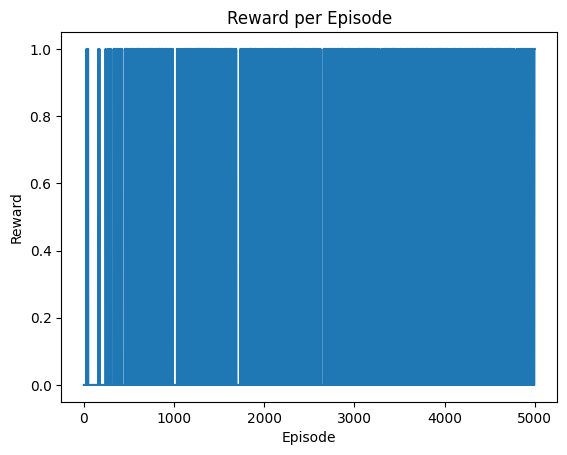

In [ ]:
def run_greedy_policy(episodes=100):
    successes = 0

    for _ in range(episodes):
        state, info = env.reset()
        done = False

        while not done:
            action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            state = next_state

            if done and reward == 1:
                successes += 1

    return successes / episodes

success_rate = run_greedy_policy()
print("Success rate:", success_rate)

import matplotlib.pyplot as plt

plt.plot(rewards_per_episode)
plt.title("Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()